# Anchored Langevin with a constant skew field

Self-contained: needs only `numpy`, `scipy` and `matplotlib`.

Heavy-tailed target, a $d=3$ Student-t with $\nu = 6$ and condition number
$\kappa = 100$:

$$q(x) = 1 + \tfrac{1}{\nu}x^{\top}\Sigma^{-1}x,\qquad
  U = \iota\log q,\qquad U_0 = \beta\log q,\qquad
  \iota = \tfrac{d+\nu}{2},\quad \beta = \iota - 1 .$$

The anchored SDE replaces $\nabla U$ by the anchor's gradient and rescales:

$$dX = -\nabla U_0(X)\,e^{U-U_0}\,dt + \sqrt{2}\,e^{(U-U_0)/2}\,dW .$$

With $\beta = \iota - 1$ we get $e^{U-U_0} = q$ exactly, the two $q$'s cancel and
the drift is **linear**, $b = -\tfrac{2\beta}{\nu}\Sigma^{-1}x$; only the scalar
diffusion $\sigma = \sqrt q$ stays state dependent.

A constant skew matrix $J_a$ is then added to the drift. Being skew it leaves
the target invariant, so the two runs sample the same distribution and differ
only in how fast they get there.

Two runs, $J = 0$ and $J_a$, from each of the two starting ensembles:

$$X_0 \sim N(0,\,10\,I_d) \qquad\text{and}\qquad X_0 \sim \mathrm{Uniform}(-5,5)^d .$$

The stepsizes are the same for both priors — equal stationary accuracy is a
property of the target and the invariant law, not of where the chain starts —
so the two figures differ only in the transient.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
# ---- parameters ---------------------------------------------------------
D, NU, KAPPA = 3, 6.0, 100.0     # target
A = 4.0                          # field strength: J_a has spectral norm A
N, REPS, STEPS = 5000, 5, 20000  # particles, replications, iterations
RAMP = 10.0                      # warm-up of the skew field, in fast relaxations
PRIORS = ("normal10", "uniform5")  # X_0 ~ N(0, 10 I)  and  X_0 ~ Uniform(-5, 5)^d

# Stepsizes equalise STATIONARY accuracy, so the two runs sit at the same
# asymptotic error and only their convergence speed differs.  Calibrated to 2%
# stationary covariance bias for J = 0.  Re-calibrate if you change A.
ETA = {"zero": 1.172e-03, "const": 1.003e-03}

## The target

In [3]:
class StudentT:
    """Student-t pi ~ q^{-iota} with the log-quadratic anchor U0 = beta log q.

        q(x)  = 1 + (1/nu) x' Sigma^-1 x
        U     = iota log q,   iota = (d + nu) / 2
        U0    = beta log q,   beta = iota - 1
        e^{U-U0} = q,  grad U0 = (2 beta/nu) Sigma^-1 x / q
        drift b = -e^{U-U0} grad U0 = -(2 beta/nu) Sigma^-1 x     (linear: q cancels)
        sigma(x) = sqrt(q)
    """

    def __init__(self, d, nu, kappa):
        self.d, self.nu = d, float(nu)
        # log-spaced eigenvalues spanning the condition number, largest = 1
        self.Sigma = np.diag(np.logspace(-np.log10(kappa), 0.0, d))
        self.Sigma_inv = np.linalg.inv(self.Sigma)
        ev, V = np.linalg.eigh(self.Sigma)
        self.Sigma_evals, self.Sigma_evecs = ev, V
        self.Sigma_half = (V * np.sqrt(ev)) @ V.T
        self.iota = 0.5 * (d + self.nu)
        self.beta = self.iota - 1.0
        self.coef = 2.0 * self.beta / self.nu

    def q(self, x):
        x = np.atleast_2d(x)
        return 1.0 + np.einsum("ni,ij,nj->n", x, self.Sigma_inv, x) / self.nu

    def grad_U0(self, x):
        x = np.atleast_2d(x)
        return self.coef * (x @ self.Sigma_inv) / self.q(x)[:, None]

    def anchor_scale(self, x):
        return self.q(x)

    def sigma(self, x):
        return np.sqrt(self.q(x))

    def sample(self, n, rng):
        z = rng.standard_normal((n, self.d))
        g = rng.chisquare(self.nu, size=n)
        return (z @ self.Sigma_half) * np.sqrt(self.nu / g)[:, None]

    def projected_scale(self, theta):
        return float(np.sqrt(theta @ self.Sigma @ theta))

    def projected_ppf(self, u, theta):
        return stats.t.ppf(u, df=self.nu, scale=self.projected_scale(theta))

    def projected_isf(self, w, theta):
        return stats.t.isf(w, df=self.nu, scale=self.projected_scale(theta))


## The skew matrix

$J_a$ is taken in the direction that maximises the spectral gap of the linear
surrogate: the skew $J$ making every eigenvalue of $(I-J)\Sigma^{-1}$ equal to
$\operatorname{Tr}(\Sigma^{-1})/d$ (Hwang–Hwang-Sheu–Sheu; Lelièvre–Nier–Pavliotis),
rescaled to spectral norm $a$.

In [4]:
def _constant_diagonal_basis(A, tol=1e-12):
    """Orthogonal Q with diag(Q A Q') constant, by Bendel-Mickey rotations."""
    A = np.asarray(A, float); d = A.shape[0]
    target = np.trace(A) / d
    N, Q = A.copy(), np.eye(d)
    fixed = np.zeros(d, bool)
    for _ in range(d - 1):
        free = np.where(~fixed)[0]
        diag = np.diag(N)[free]
        if np.all(np.abs(diag - target) < tol):
            break
        i, j = free[int(np.argmin(diag))], free[int(np.argmax(diag))]
        p, q_, r = N[i, i], N[j, j], N[i, j]
        if abs(p - target) < tol:
            fixed[i] = True
            continue
        a2, b2, c2 = q_ - target, 2.0 * r, p - target
        if abs(a2) < tol:
            t = -c2 / b2 if abs(b2) > tol else 0.0
        else:
            disc = max(b2 * b2 - 4.0 * a2 * c2, 0.0)
            t = min([(-b2 + np.sqrt(disc)) / (2 * a2),
                     (-b2 - np.sqrt(disc)) / (2 * a2)], key=abs)
        c = 1.0 / np.sqrt(1.0 + t * t); s = t * c
        G = np.eye(d); G[i, i] = G[j, j] = c; G[i, j] = s; G[j, i] = -s
        N = G @ N @ G.T; Q = G @ Q
        fixed[i] = True
    return Q


def optimal_skew(A):
    """Skew J making every eigenvalue of (I - J)A equal to Tr(A)/d."""
    A = np.asarray(A, float); d = A.shape[0]
    if d < 2:
        return np.zeros((d, d))
    ev, V = np.linalg.eigh(A)
    A_inv_half = (V * (1.0 / np.sqrt(ev))) @ V.T
    Q = _constant_diagonal_basis(A)
    L = np.tril(Q @ A @ Q.T, -1)
    K = A_inv_half @ (Q.T @ (L.T - L) @ Q) @ A_inv_half
    return -0.5 * (K - K.T)


## The sampler

A warm-up ramp holds the skew part back over the first few relaxations of the
stiffest direction. Starting from a prior much wider than the target, the
rotation would otherwise convert the excess stiff spread into a transient
excursion down the soft axis — a hump in the curve before it falls. A scaled
skew field is still skew, so the target is preserved at every iteration.

In [5]:
def make_prior(kind, d, n, rng):
    """The two starting ensembles.

        normal10   X_0 ~ N(0, 10 I_d)          covariance 10 I
        uniform5   X_0 ~ Uniform(-5, 5)^d      covariance (100/12) I = 8.33 I

    The uniform one is bounded, so it has no tail to contract; the ramp below
    is calibrated on the Gaussian's excess spread and carries over, but that is
    a measurement, not something to assume.
    """
    if kind == "normal10":
        return rng.standard_normal((n, d)) * np.sqrt(10.0)
    if kind == "uniform5":
        return rng.uniform(-5.0, 5.0, size=(n, d))
    raise ValueError(f"unknown prior {kind!r}")


def warmup_schedule(target, eta, n_relax=10.0):
    """Smoothstep over n_relax relaxations of the fastest direction."""
    k_relax = 1.0 / (eta * target.coef / target.Sigma_evals.min())
    K = max(1.0, n_relax * k_relax)

    def sched(k):
        u = min(1.0, k / K)
        return u * u * (3.0 - 2.0 * u)
    return sched


def anchored_step(target, eta, J=None, schedule=None):
    """Euler-Maruyama for dX = [-I + J] e^{U-U0} grad U0 dt + sqrt(2) sigma dW."""
    sq = np.sqrt(2.0 * eta)
    counter = {"k": 0}

    def step(x, rng):
        s_k = 1.0 if schedule is None else float(schedule(counter["k"]))
        counter["k"] += 1
        g = target.grad_U0(x)
        rot = g if J is None else g @ J.T
        drift = target.anchor_scale(x)[:, None] * ((0.0 if J is None else s_k) * rot - g)
        return x + eta * drift + sq * (target.sigma(x)[:, None] * rng.standard_normal(x.shape))
    return step


## The metric

Sliced 2-Wasserstein against the *exact* projected quantiles: every projection
of a multivariate Student-t is a univariate Student-t, so no sampling noise
enters through the reference side. The tail cells need care — with $\nu = 6$ the
quantile function diverges at the ends, and the naive midpoint estimator
truncates that contribution.

In [6]:
def _cell_quadrature(n, n_quad=8, n_tail=48, tail_power=8):
    """Nodes and weights for W2^2 = int_0^1 (F_n^-1 - F^-1)^2 du.

    Interior cells get Gauss-Legendre in u.  The two extreme cells, where a
    heavy-tailed quantile blows up, are integrated in the tail probability with
    w = v^p / n, which makes the integrand smooth.  The upper cell goes through
    the inverse survival function so 1 - w is never formed (it would round to 1
    and give +inf).
    """
    gl_x, gl_w = np.polynomial.legendre.leggauss(n_quad)
    off, wgt = 0.5 * (gl_x + 1.0), 0.5 * gl_w / n
    j = np.arange(1, n - 1)
    u_mid = (j[:, None] + off[None, :]) / n
    w_mid = np.tile(wgt, (n - 2, 1))
    tx, tw = np.polynomial.legendre.leggauss(n_tail)
    v, vw, a, p = 0.5 * (tx + 1.0), 0.5 * tw, 1.0 / n, tail_power
    return u_mid, w_mid, a * v ** p, a * p * v ** (p - 1) * vw


_QUAD, _REF = {}, {}


def w2_sq_1d(x, ppf, isf, key):
    x = np.sort(np.asarray(x, float).ravel())
    n = x.size
    if n not in _QUAD:
        _QUAD[n] = _cell_quadrature(n)
    u_mid, w_mid, v_tail, w_tail = _QUAD[n]
    if (n, key) not in _REF:
        _REF[(n, key)] = (ppf(u_mid), ppf(v_tail), isf(v_tail))
    ref_mid, ref_lo, ref_hi = _REF[(n, key)]
    return (float(np.sum(w_mid * (x[1:-1, None] - ref_mid) ** 2))
            + float(np.sum(w_tail * (x[0] - ref_lo) ** 2))
            + float(np.sum(w_tail * (x[-1] - ref_hi) ** 2)))


def sliced_w2(samples, target):
    """d axis-aligned projections, each against the exact projected t quantiles."""
    total = 0.0
    for theta in np.eye(target.d):
        total += w2_sq_1d(samples @ theta,
                          lambda u, th=theta: target.projected_ppf(u, th),
                          lambda w, th=theta: target.projected_isf(w, th),
                          key=(target.nu, target.projected_scale(theta)))
    return float(np.sqrt(total / target.d))


In [7]:
def log_schedule(n_steps, n_points=90):
    pts = np.unique(np.round(np.geomspace(1, n_steps, n_points)).astype(int))
    return sorted(set([0] + pts.tolist() + [n_steps]))


## Run

In [8]:
target = StudentT(D, NU, KAPPA)
J_opt = optimal_skew(target.Sigma_inv)
J_a = A * J_opt / np.linalg.norm(J_opt, 2)          # spectral norm exactly A
record_at = log_schedule(STEPS, 90)

print(f"Sigma eigenvalues : {np.sort(target.Sigma_evals)}")
print(f"iota = {target.iota}, beta = {target.beta}")
print(f"\nJ_a (spectral norm {np.linalg.norm(J_a, 2):.2f}):\n{np.round(J_a, 4)}")

Sigma eigenvalues : [0.01 0.1  1.  ]
iota = 4.5, beta = 3.5

J_a (spectral norm 4.00):
[[-0.     -0.3866 -2.7034]
 [ 0.3866 -0.     -2.9227]
 [ 2.7034  2.9227 -0.    ]]


In [9]:
def convergence_curve(J, eta, prior):
    """Sliced 2-Wasserstein to the exact target, averaged over replications."""
    curves = []
    for r in range(REPS):
        x = make_prior(prior, D, N, np.random.default_rng(500 + r))
        schedule = warmup_schedule(target, eta, RAMP) if J is not None else None
        step = anchored_step(target, eta, J, schedule)
        rng = np.random.default_rng(9000 + r)
        w, k = [], 0
        for t in record_at:
            while k < t:
                x = step(x, rng)
                k += 1
            w.append(sliced_w2(x, target))
        curves.append(w)
    return np.mean(curves, axis=0)

curves = {}
for prior in PRIORS:
    curves[prior] = {"zero":  convergence_curve(None, ETA["zero"], prior),
                     "const": convergence_curve(J_a,  ETA["const"], prior)}
    print(f"{prior}: done")

normal10: done


uniform5: done


## Plot

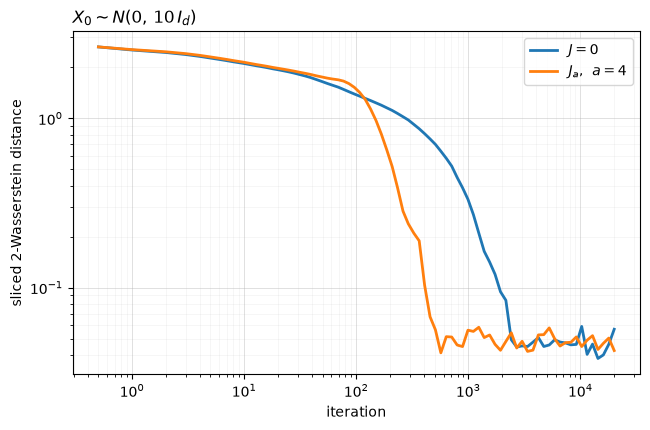

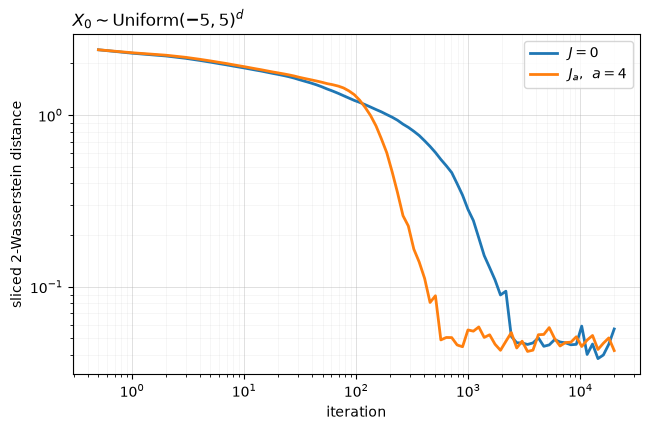

In [10]:
PRIOR_TITLE = {"normal10": r"$X_0 \sim N(0,\,10\,I_d)$",
               "uniform5": r"$X_0 \sim \mathrm{Uniform}(-5,5)^d$"}

it = np.asarray(record_at, dtype=float)
it[0] = it[1] / 2                       # first point is iteration 0; nudge onto the log axis

for prior in PRIORS:
    fig, ax = plt.subplots(figsize=(6.6, 4.4))
    ax.plot(it, curves[prior]["zero"],  lw=2.0, label=r"$J = 0$")
    ax.plot(it, curves[prior]["const"], lw=2.0, label=rf"$J_a$,  $a = {A:g}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("iteration")
    ax.set_ylabel("sliced 2-Wasserstein distance")
    ax.set_title(PRIOR_TITLE[prior], loc="left")
    ax.grid(True, which="major", lw=0.6, alpha=0.45)
    ax.grid(True, which="minor", lw=0.4, alpha=0.20)
    ax.set_axisbelow(True)              # gridlines behind the curves
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"anchored_constant_field_{prior}.png", dpi=200)
plt.show()